In [2]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")

In [3]:
controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5]
controly = [0. 0.1 0.3 0.5 0. 0.6 0.5 0.1 0.] .+ 1.
#controlx = [-1.5  0. 1.5]
#controly = [0.  1.1 0.] .+ 1.
#controlx = [-1.5   1.5]
#controly = [0.  1.] .+ 1.
#controlx = transpose([-1.5 + i / 10 * 3 for i in 1:7])
#controly = transpose([i / 10 * 1 for i in 1:7])
control = vcat(controlx, controly)
n::Int64 = size(control)[2]

9

In [4]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray = 1000
source0 = (Ray([-1. +  2*i / Nray, 0. ], pi / 2. ) for i in 0:Nray)
xstar = 0.

0.0

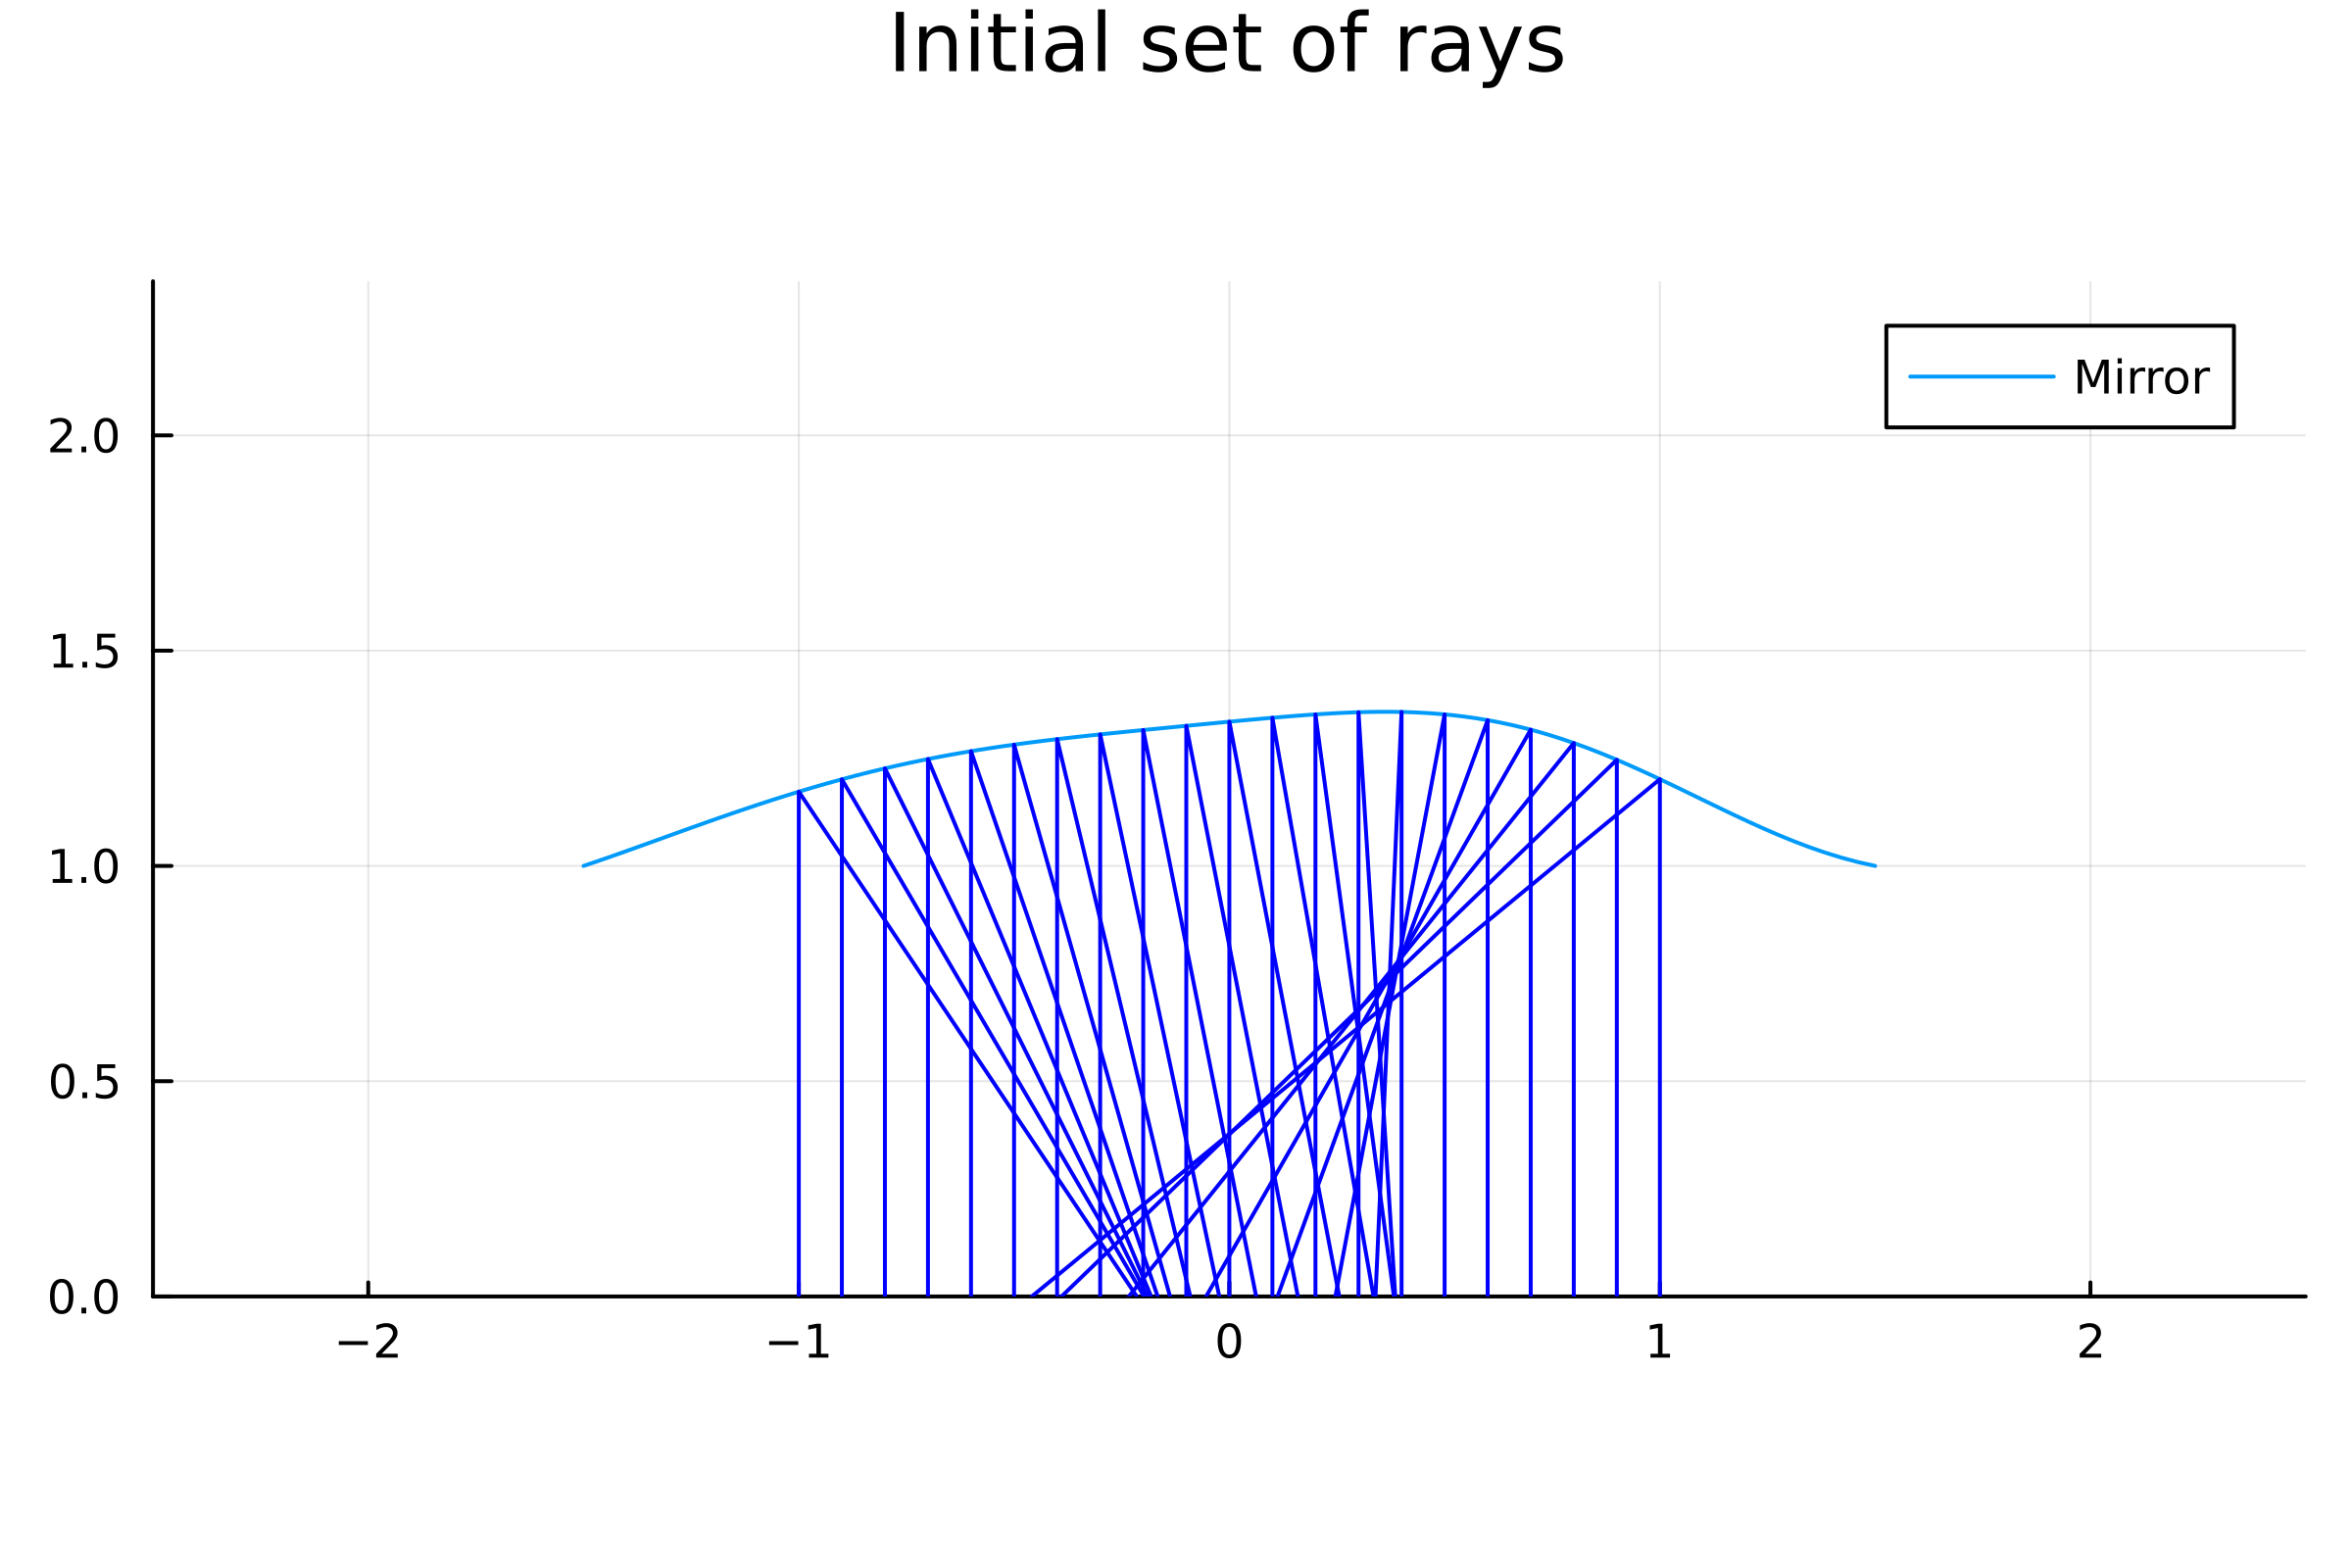

In [5]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400,title = "Initial set of rays")
source4plot = (Ray([-1. +  2*i / 20, 0. ], pi / 2. ) for i in 0:20)
for ray in source4plot
    plot!(ray)
end
savefig("rays_verif_der.png")
display(plt)

In [6]:
#Fonction coût
function cost0(control::Matrix{Float64})::Float64
    return sum( abs( projectionplanfocal(billiard(control,ray) ).pos[1] - xstar)^2. for ray in source0) / length(source0)
    #return sum( (1. + sin(projectionplanfocal(billiard(control,ray) ).angle))^2 for ray in source0) / length(source0)
end
cost0(control)

0.05957980850476652

In [7]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray)::Vector{Float64}
    return [2. * (ray.pos[1] - xstar), 0.]
    #return [0., 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return [0., 0.]
    #return 2. * [0., 1. + sin(ray.angle)]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf), diffj0xi(rayf))
end



jtildexi (generic function with 1 method)

In [8]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

In [9]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    for ray in source0
        # on projette sur le miroir et on récupère le $t$ de param
        t::Float64 = intersectionLine(control, ray) 
        dic = geometricquantities(control, t)
        theta = ray.angle
        #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
        sdot = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
        thetaf = atan( sin(theta) - 2. * sdot * dic["normal"][2], cos(theta) - 2. * sdot * dic["normal"][1] )
        #on calcule les termes de la dérivée de formes
        sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
        rayr = Ray(dic["point"], thetaf)
        djx = jtildex(rayr)
        djxi = jtildexi(rayr)
        gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
        gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
    end
    return 2. * gradient ./ length(source0)
end


gradientj0 (generic function with 1 method)

In [10]:
dir = zeros(2,n)
posx = 1
posy = 4
dir[posx,posy] = 1.
#dir = vcat(zeros(1,n),ones(1,n))


1.0

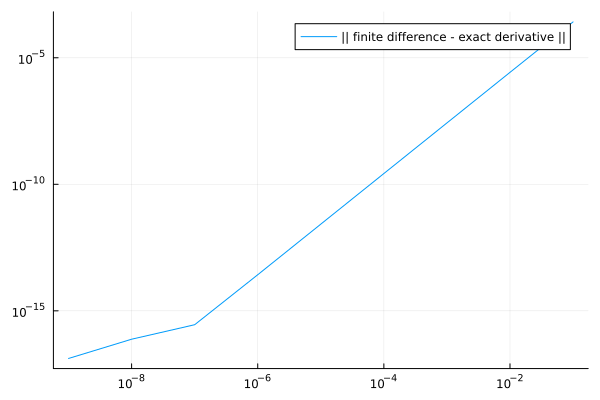

In [18]:
N = 9
residu = zeros(2,N)
for k in 1:N
    residu[1,k] = ( cost0(control + (10.)^(-k) .* dir ) - cost0(control) ) - dot(gradientj0(control), (10.)^(-k) .* dir) 
end
absX =[ k for k in 1:N]
absX =(10.).^((-absX))
#plt = plot(absX,residu[1,:],label= "Différence finie")
#plot!(absX,residu[2,:],label= "Gradient")

plt = plot(absX,residu[1,:], xaxis =:log, yaxis =:log, label= "|| finite difference - exact derivative ||")
#plot!(absX,residu[2,:],label= "Exact derivative", xaxis =:log)
display(plt)

In [11]:
# Dérivées de formes OK si miroir plan et j ne dépend que de x avec 7 points de controle
# Dérivées de formes OK si miroir plan et j ne dépend que de xi avec 7 points de controle
# Donc a priori le 3 eme terme est correcte ainsi que les dterm 1 et sdterm 3

#on peut incriminer sdterm2 et/ou la courbure

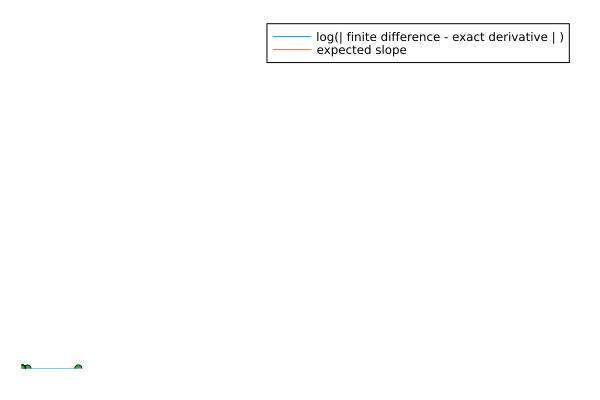

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194


In [19]:
N = 9
residu = zeros(2,N)
for k in 1:N
    residu[1,k] =  abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control)  -  (10.)^(-k) * dot(gradientj0(control), dir) ) ) 
end
absX =[ k for k in 1:N]
absX =(10.).^((-absX))
#println(absX)
plt = plot(absX,residu[1,:],label= "log(| finite difference - exact derivative | )", xaxis =:log, yaxis =:log)
line = residu[1,1] .- [k for k in 1:N]
plot!(absX, line, label = "expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
display(plt)

In [13]:
# METTRE PLUSIEURS "DÉRIVÉES DIRECIOTNNELLES SUR LES GRAPHES
# le log et celui d'avant (couper à 10 -12
# plot avec les rayons

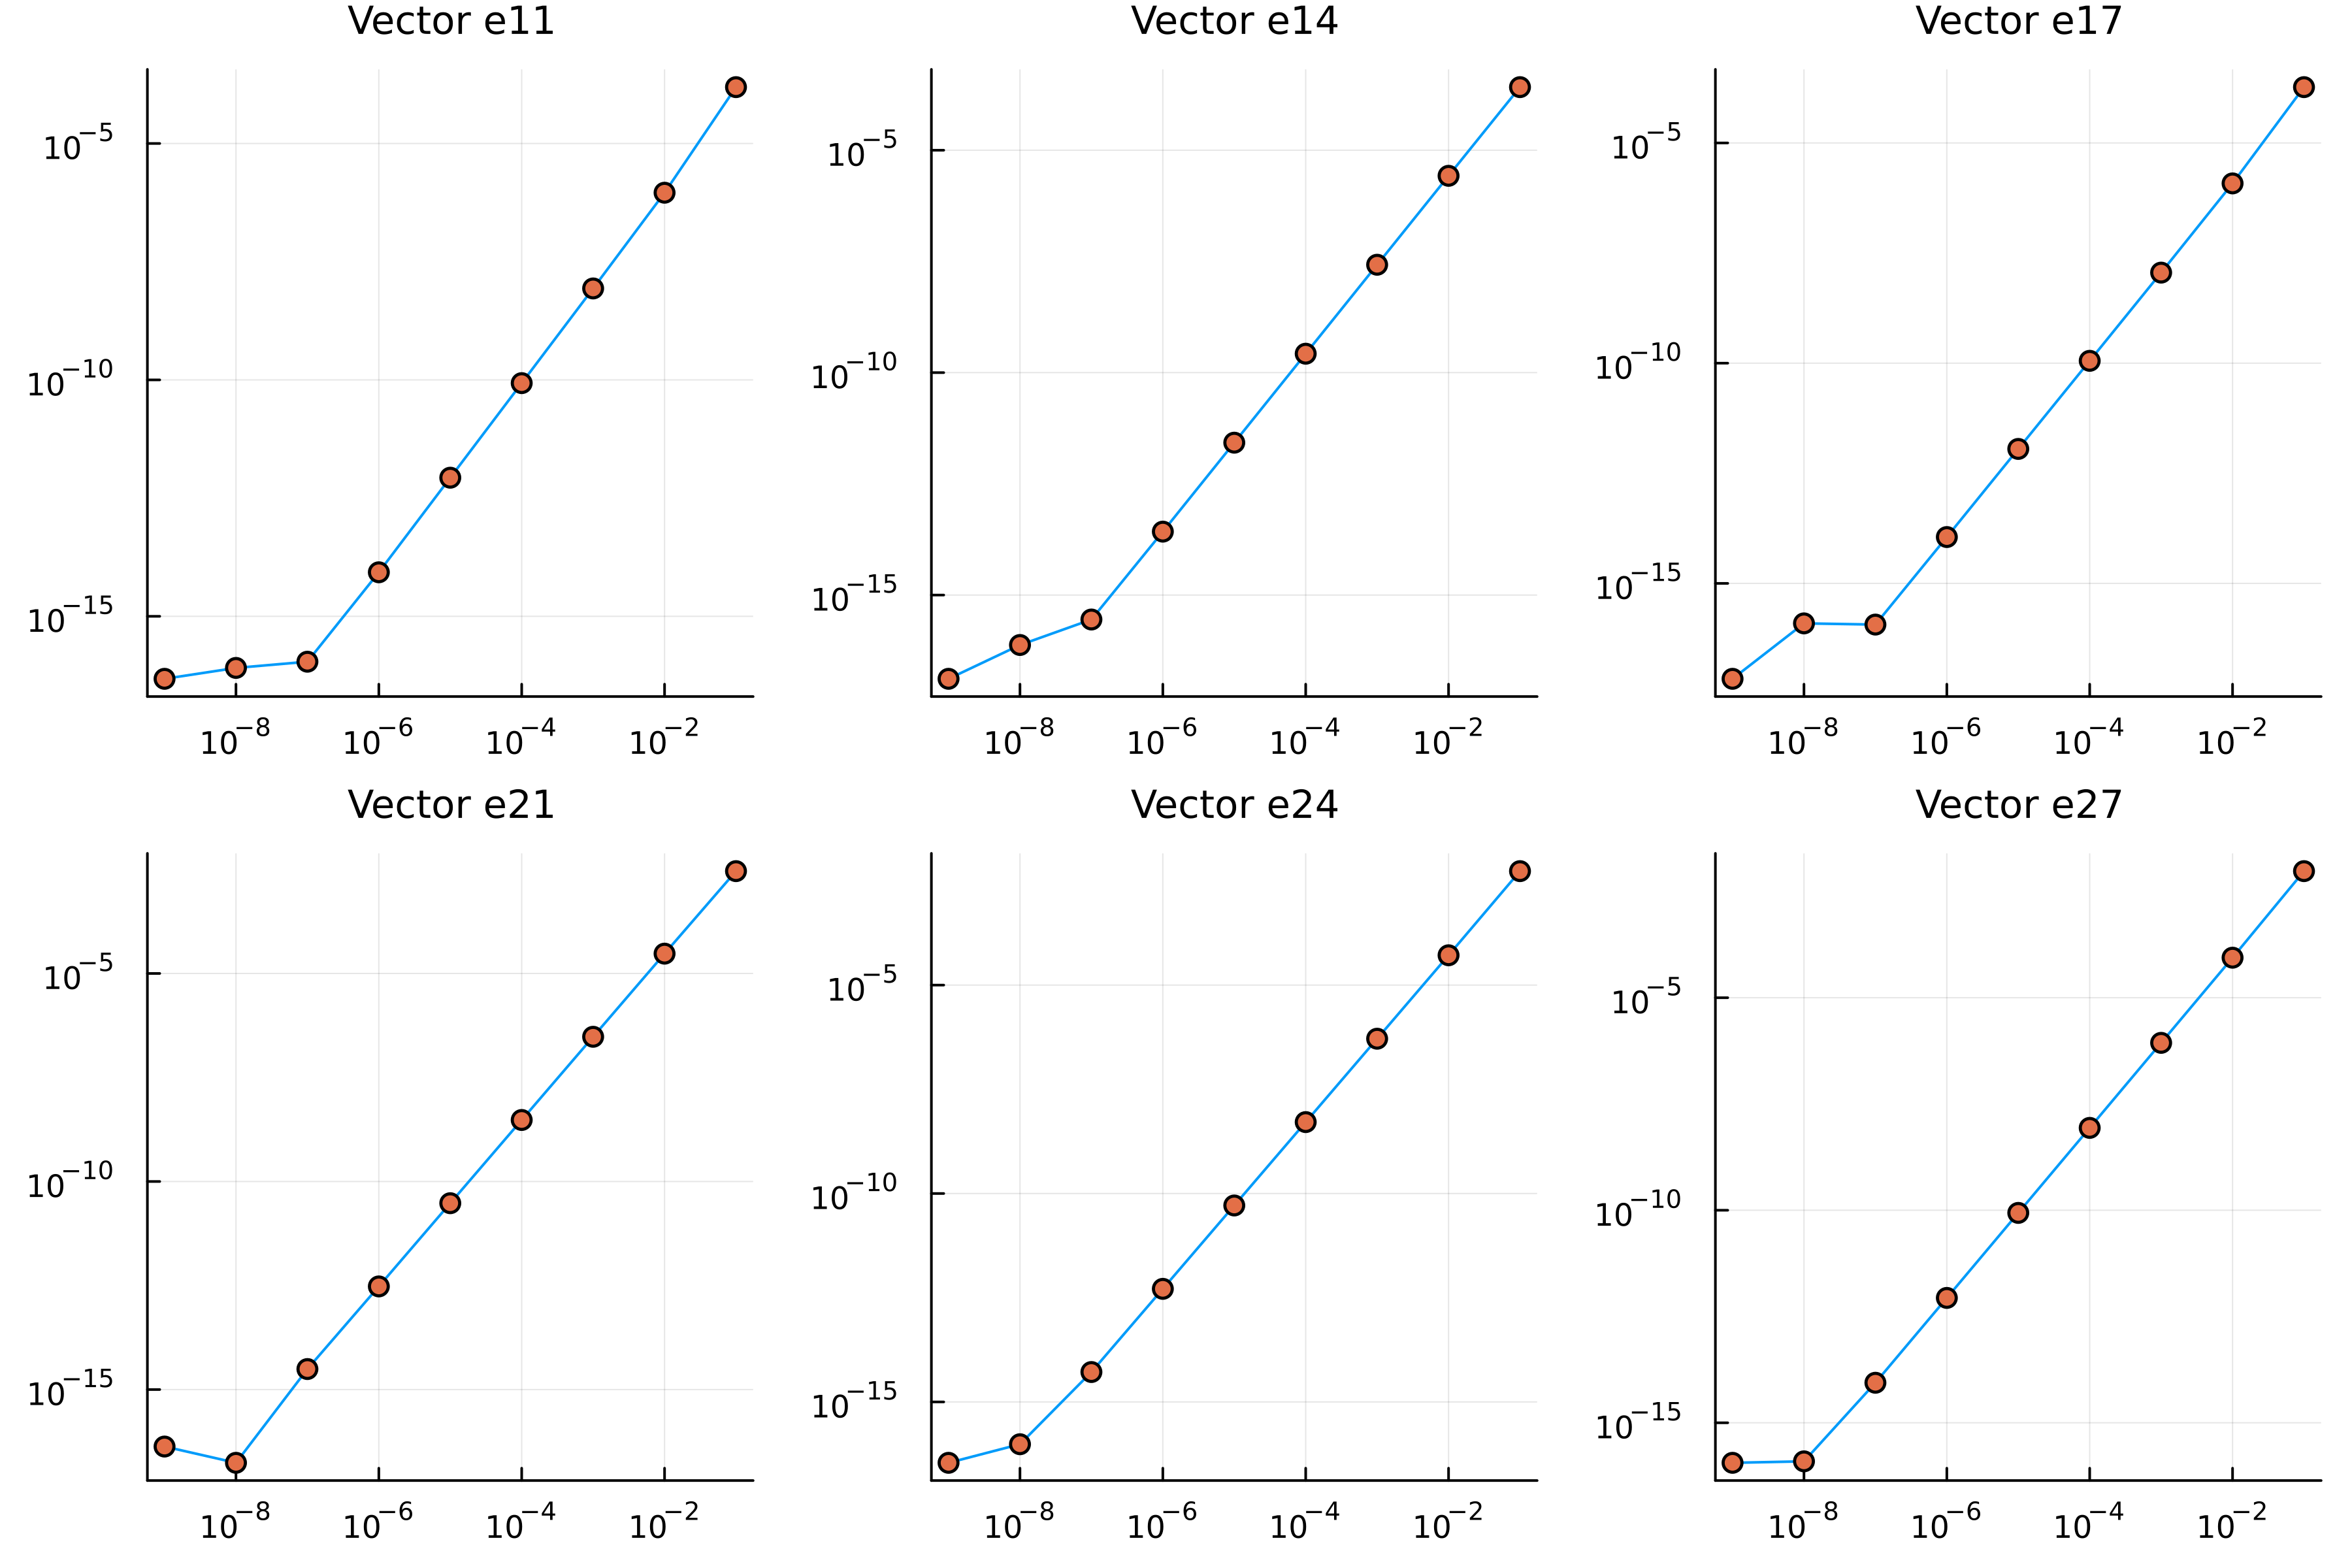

In [30]:
dir = zeros(2,n)
N = 9
residu = zeros(2,N)
absX =[ k for k in 1:N]
absX = (10.).^(-absX)
#labelname = "|j(x+h) - j(x) - j'(x)h |"
labelname = false

## 1
posx = 1
posy = 1
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir) )
end

plt11 = plot(absX[:],residu[1,:],label= labelname, xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e11" , titlefontsize = 10 , dpi = 400, legend =:topleft )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,  xguidefontsize = 10, xaxis =:log  )
dir[posx,posy] = 0.

## 14##
posx = 1
posy = 4
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir) )
end


plt14 = plot(absX[:],residu[1,:],label= labelname, xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e14" , titlefontsize = 10 , dpi = 400 , legend =:topleft )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,  xguidefontsize = 10, xaxis =:log  )
dir[posx,posy] = 0.

### 1 7
posx = 1
posy = 7
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir) )
end

plt17 = plot(absX[:],residu[1,:],label= labelname, xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e17" , titlefontsize = 10, dpi = 400, legend =:topleft  )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,  xguidefontsize = 10, xaxis =:log  )
dir[posx,posy] = 0.

## 21 ##
posx = 2
posy = 1
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir) )
end

plt21 = plot(absX[:],residu[1,:],label= labelname , xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e21" , titlefontsize = 10 , dpi = 400, legend =:topleft  )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,  xguidefontsize = 10, xaxis =:log  )
dir[posx,posy] = 0.

posx = 2
posy = 4
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir))
end


plt24 = plot(absX[:],residu[1,:],label= labelname, xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e24" , titlefontsize = 10, dpi = 400, legend =:topleft )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,  xguidefontsize = 10, xaxis =:log  )
dir[posx,posy] = 0.


### 2 7
posx = 2
posy = 7
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = abs( ( cost0(control +  (10.)^(-k) .* dir ) - cost0(control) ) -  (10.)^(-k)  * dot(gradientj0(control), dir) )
end

plt27 = plot(absX[:],residu[1,:],label= labelname,  xguidefontsize = 10 , xaxis =:log, yaxis =:log, title = "Vector e27" , titlefontsize = 10, dpi = 400, legend =:topleft )
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
#plot!(absX[:],residu[2,:],label= "Exact derivative " ,   xguidefontsize = 10, xaxis =:log )
#annotate!((10.)^(-5), 0.5, "Basis vector e27")
dir[posx,posy] = 0.

plt = plot(plt11, plt14, plt17, plt21, plt24, plt27,  layout = 6, size = (900,600), dpi = 400)
savefig("layout_fdiff_exactdiff.png")
display(plt)


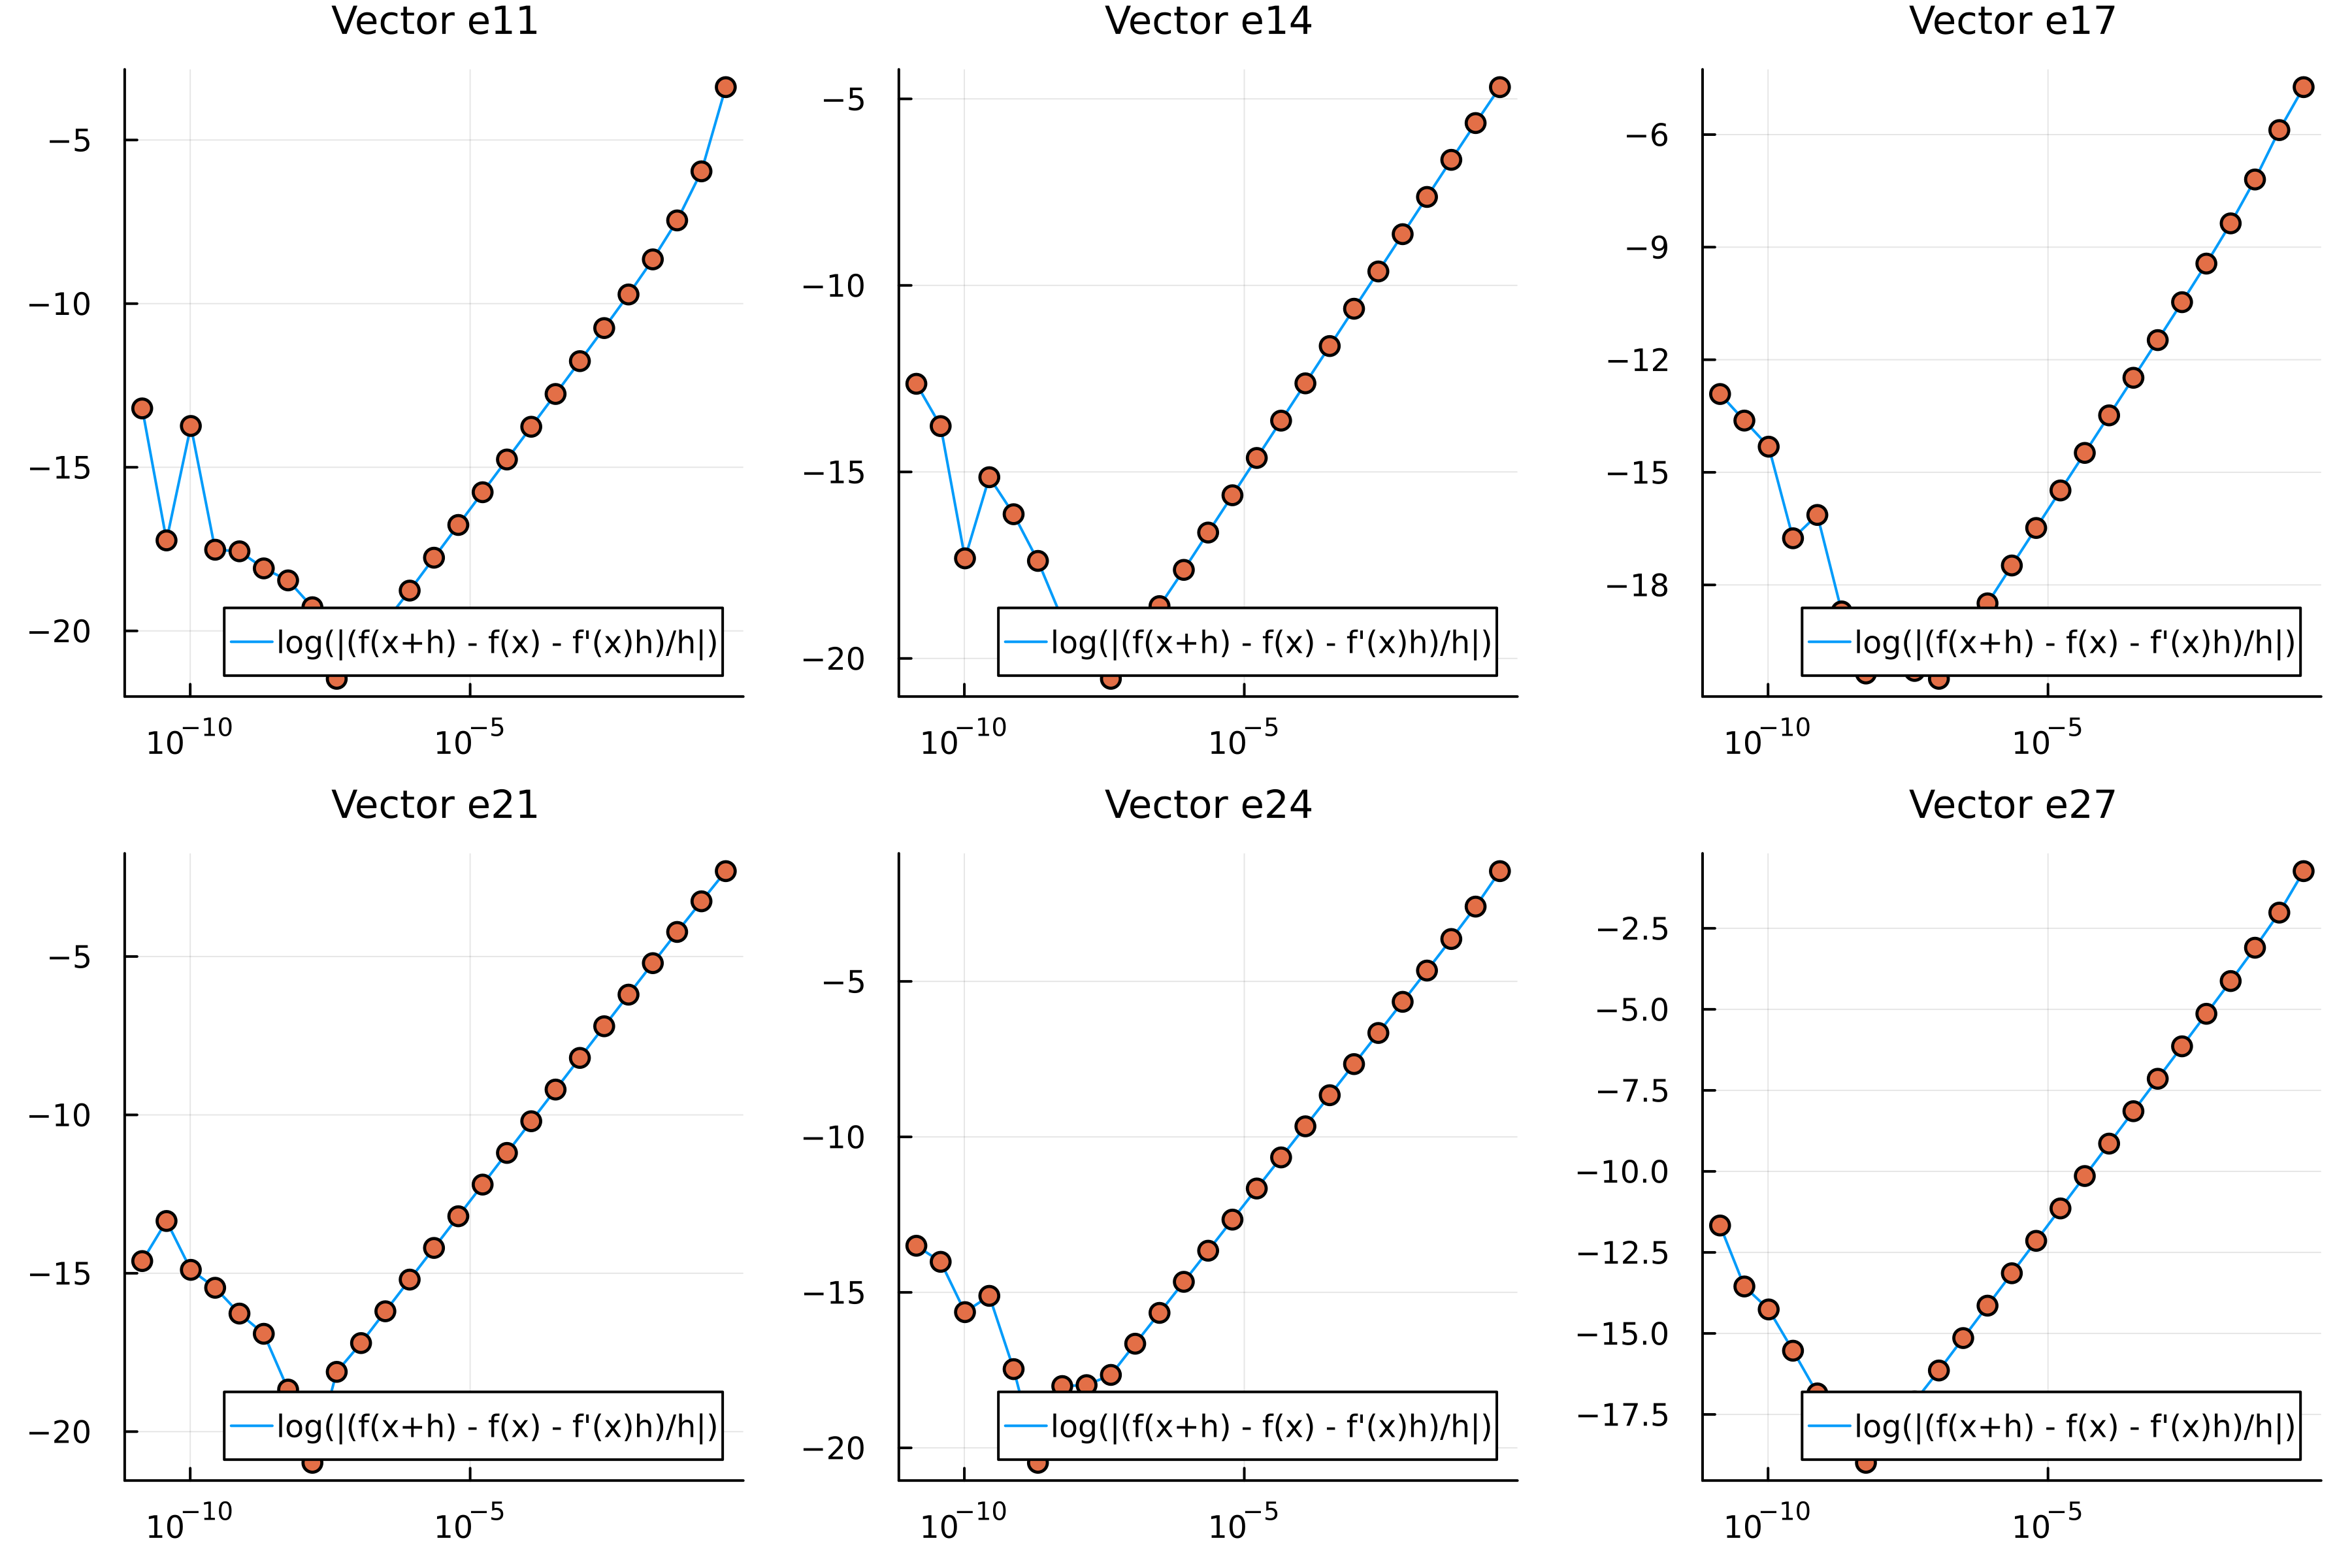

In [22]:
dir = zeros(2,n)
N = 25
residu = zeros(2,N)
absX =[ k for k in 1:N]
absX = exp.(-absX)

#### 11 ###

posx = 1
posy = 1
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt11 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)" , xaxis =:log, title = "Vector e11", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.

#### 14 ###

posx = 1
posy = 4
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt14 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)" , xaxis =:log, title = "Vector e14", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.

#### 17 ###

posx = 1
posy = 7
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt17 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)" , xaxis =:log, title = "Vector e17", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.


#### 21 ###

posx = 2
posy = 1
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt21 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)", xaxis =:log, title = "Vector e21", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.

#### 24 ###
posx = 2
posy = 4
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt24 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)" , xaxis =:log, title = "Vector e24", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.

#### 27 ###
posx = 2
posy = 7
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = log( abs( ( cost0(control + exp(-k) .* dir ) - cost0(control)  - exp(-k) * dot(gradientj0(control), dir) ) / exp(-k) ) )
end
residu[2,:] = ones(N) * dot(gradientj0(control), dir)

plt27 = plot(absX,residu[1,:],label= "log(|(f(x+h) - f(x) - f'(x)h)/h|)", xaxis =:log, title = "Vector e27", titlefontsize = 10, dpi = 400, legend =:bottomright)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log, xlabel = "step")
scatter!(absX,residu[1,:], label = false, xaxis =:log)
dir[posx,posy] = 0.

plt = plot(plt11, plt14, plt17,  plt21, plt24, plt27,  layout = 6, size = (900,600), dpi = 400)
savefig("layout_verif_linear_behave.png")
display(plt)